<div style="width: 100%; overflow: hidden;">
    <div style="width: 150px; float: left;"> <img src="https://raw.githubusercontent.com/DataForScience/Networks/master/data/D4Sci_logo_ball.png" alt="Data For Science, Inc" align="left" border="0"> </div>
    <div style="float: left; margin-left: 10px;"> 
<h1>Small Language Model</h1>
        <p>Bruno Gonçalves<br/>
        <a href="http://www.data4sci.com/">www.data4sci.com</a><br/>
            @bgoncalves, @data4sci</p></div>
</div>

In [1]:
import os
import pickle

from collections import defaultdict, Counter

import numpy as np
import matplotlib.pyplot as plt

from datasets import load_dataset

import nltk
from nltk.util import ngrams
from nltk.tokenize import word_tokenize

from tqdm.notebook import tqdm

import watermark

%load_ext watermark
%matplotlib inline

We print the versions of the libraries we use, for future reference.

In [2]:
%watermark -n -v -m -g -iv

Python implementation: CPython
Python version       : 3.13.13
IPython version      : 9.12.0

Compiler    : Clang 22.1.3 
OS          : Darwin
Release     : 25.5.0
Machine     : arm64
Processor   : arm
CPU cores   : 16
Architecture: 64bit

Git hash: 19b45ca998ac6deefc7af8a3a86bb08f5ada39a4

datasets  : 5.0.0
matplotlib: 3.10.8
nltk      : 3.9.4
numpy     : 2.4.4
tqdm      : 4.67.3
watermark : 2.6.0



Load the default figure style.

In [3]:
plt.style.use('d4sci.mplstyle')
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

NLTK splits text into words with a tokenizer. The tokenizer needs two small data files. We download them once.

## The data: WikiText-103

We build the model on WikiText-103. It is a standard benchmark for language models, drawn from Wikipedia articles that editors marked Good or Featured. The training split holds about 103 million words across roughly 28,000 articles. We use the raw build, which keeps the original capitalization and punctuation and does not hide rare words behind a placeholder token.

The dataset arrives split into lines. Each row is one line of an article, a heading, or a blank separator. Loading the training split runs a download the first time and reads from cache after that.

In [4]:
wikitext = load_dataset("wikitext", "wikitext-103-raw-v1", split="train")
wikitext

Dataset({
    features: ['text'],
    num_rows: 1801350
})

Let me look at the raw rows before any counting. A quick scan shows the shape of the text and the blank lines we will skip.

In [5]:
n_rows = len(wikitext)
print(f"Total rows: {n_rows:,}")

# Count rows that are blank or whitespace only.
n_blank = sum(1 for row in wikitext["text"] if not row.strip())
print(f"Blank rows:  {n_blank:,} ({100 * n_blank / n_rows:.1f}%)")
print(f"Text rows:   {n_rows - n_blank:,}")

# Show a few non-blank rows, trimmed for display.
shown = 0
for row in wikitext["text"]:
    line = row.strip()
    if line:
        print(repr(line[:110]))
        shown += 1
    if shown == 6:
        break

Total rows: 1,801,350
Blank rows:  636,321 (35.3%)
Text rows:   1,165,029
'= Valkyria Chronicles III ='
'Senjō no Valkyria 3 : Unrecorded Chronicles ( Japanese : 戦場のヴァルキュリア3 , lit . Valkyria of the Battlefield 3 ) ,'
'The game began development in 2010 , carrying over a large portion of the work done on Valkyria Chronicles II '
'It met with positive sales in Japan , and was praised by both Japanese and western critics . After release , i'
'= = Gameplay = ='
'As with previous Valkyira Chronicles games , Valkyria Chronicles III is a tactical role @-@ playing game where'


## How long are the rows?

Word counts per row tell us how the text is chunked. Headings are short. Article paragraphs run long. Tokenizing all 1.8 million rows would take several minutes, so we draw a sample of 20,000 non-blank rows for the data study and chart the spread. The model later runs on the full corpus.

In [6]:
SAMPLE_ROWS = 20000

# Collect non-blank rows up to the sample size.
sample_texts = []
for row in wikitext["text"]:
    if row.strip():
        sample_texts.append(row)
    if len(sample_texts) == SAMPLE_ROWS:
        break

print(f"Sampled {len(sample_texts):,} non-blank rows for the data study")

Sampled 20,000 non-blank rows for the data study


In [7]:
sample_tokens = [word_tokenize(t) for t in tqdm(sample_texts, desc="Tokenizing sample")]
lengths = np.array([len(toks) for toks in sample_tokens])

print(f"Tokens in sample:      {lengths.sum():,}")
print(f"Mean tokens per row:   {lengths.mean():.1f}")
print(f"Median tokens per row: {np.median(lengths):.0f}")
print(f"Longest row:           {lengths.max()} tokens")

Tokenizing sample:   0%|          | 0/20000 [00:00<?, ?it/s]

Tokens in sample:      1,758,094
Mean tokens per row:   87.9
Median tokens per row: 75
Longest row:           711 tokens


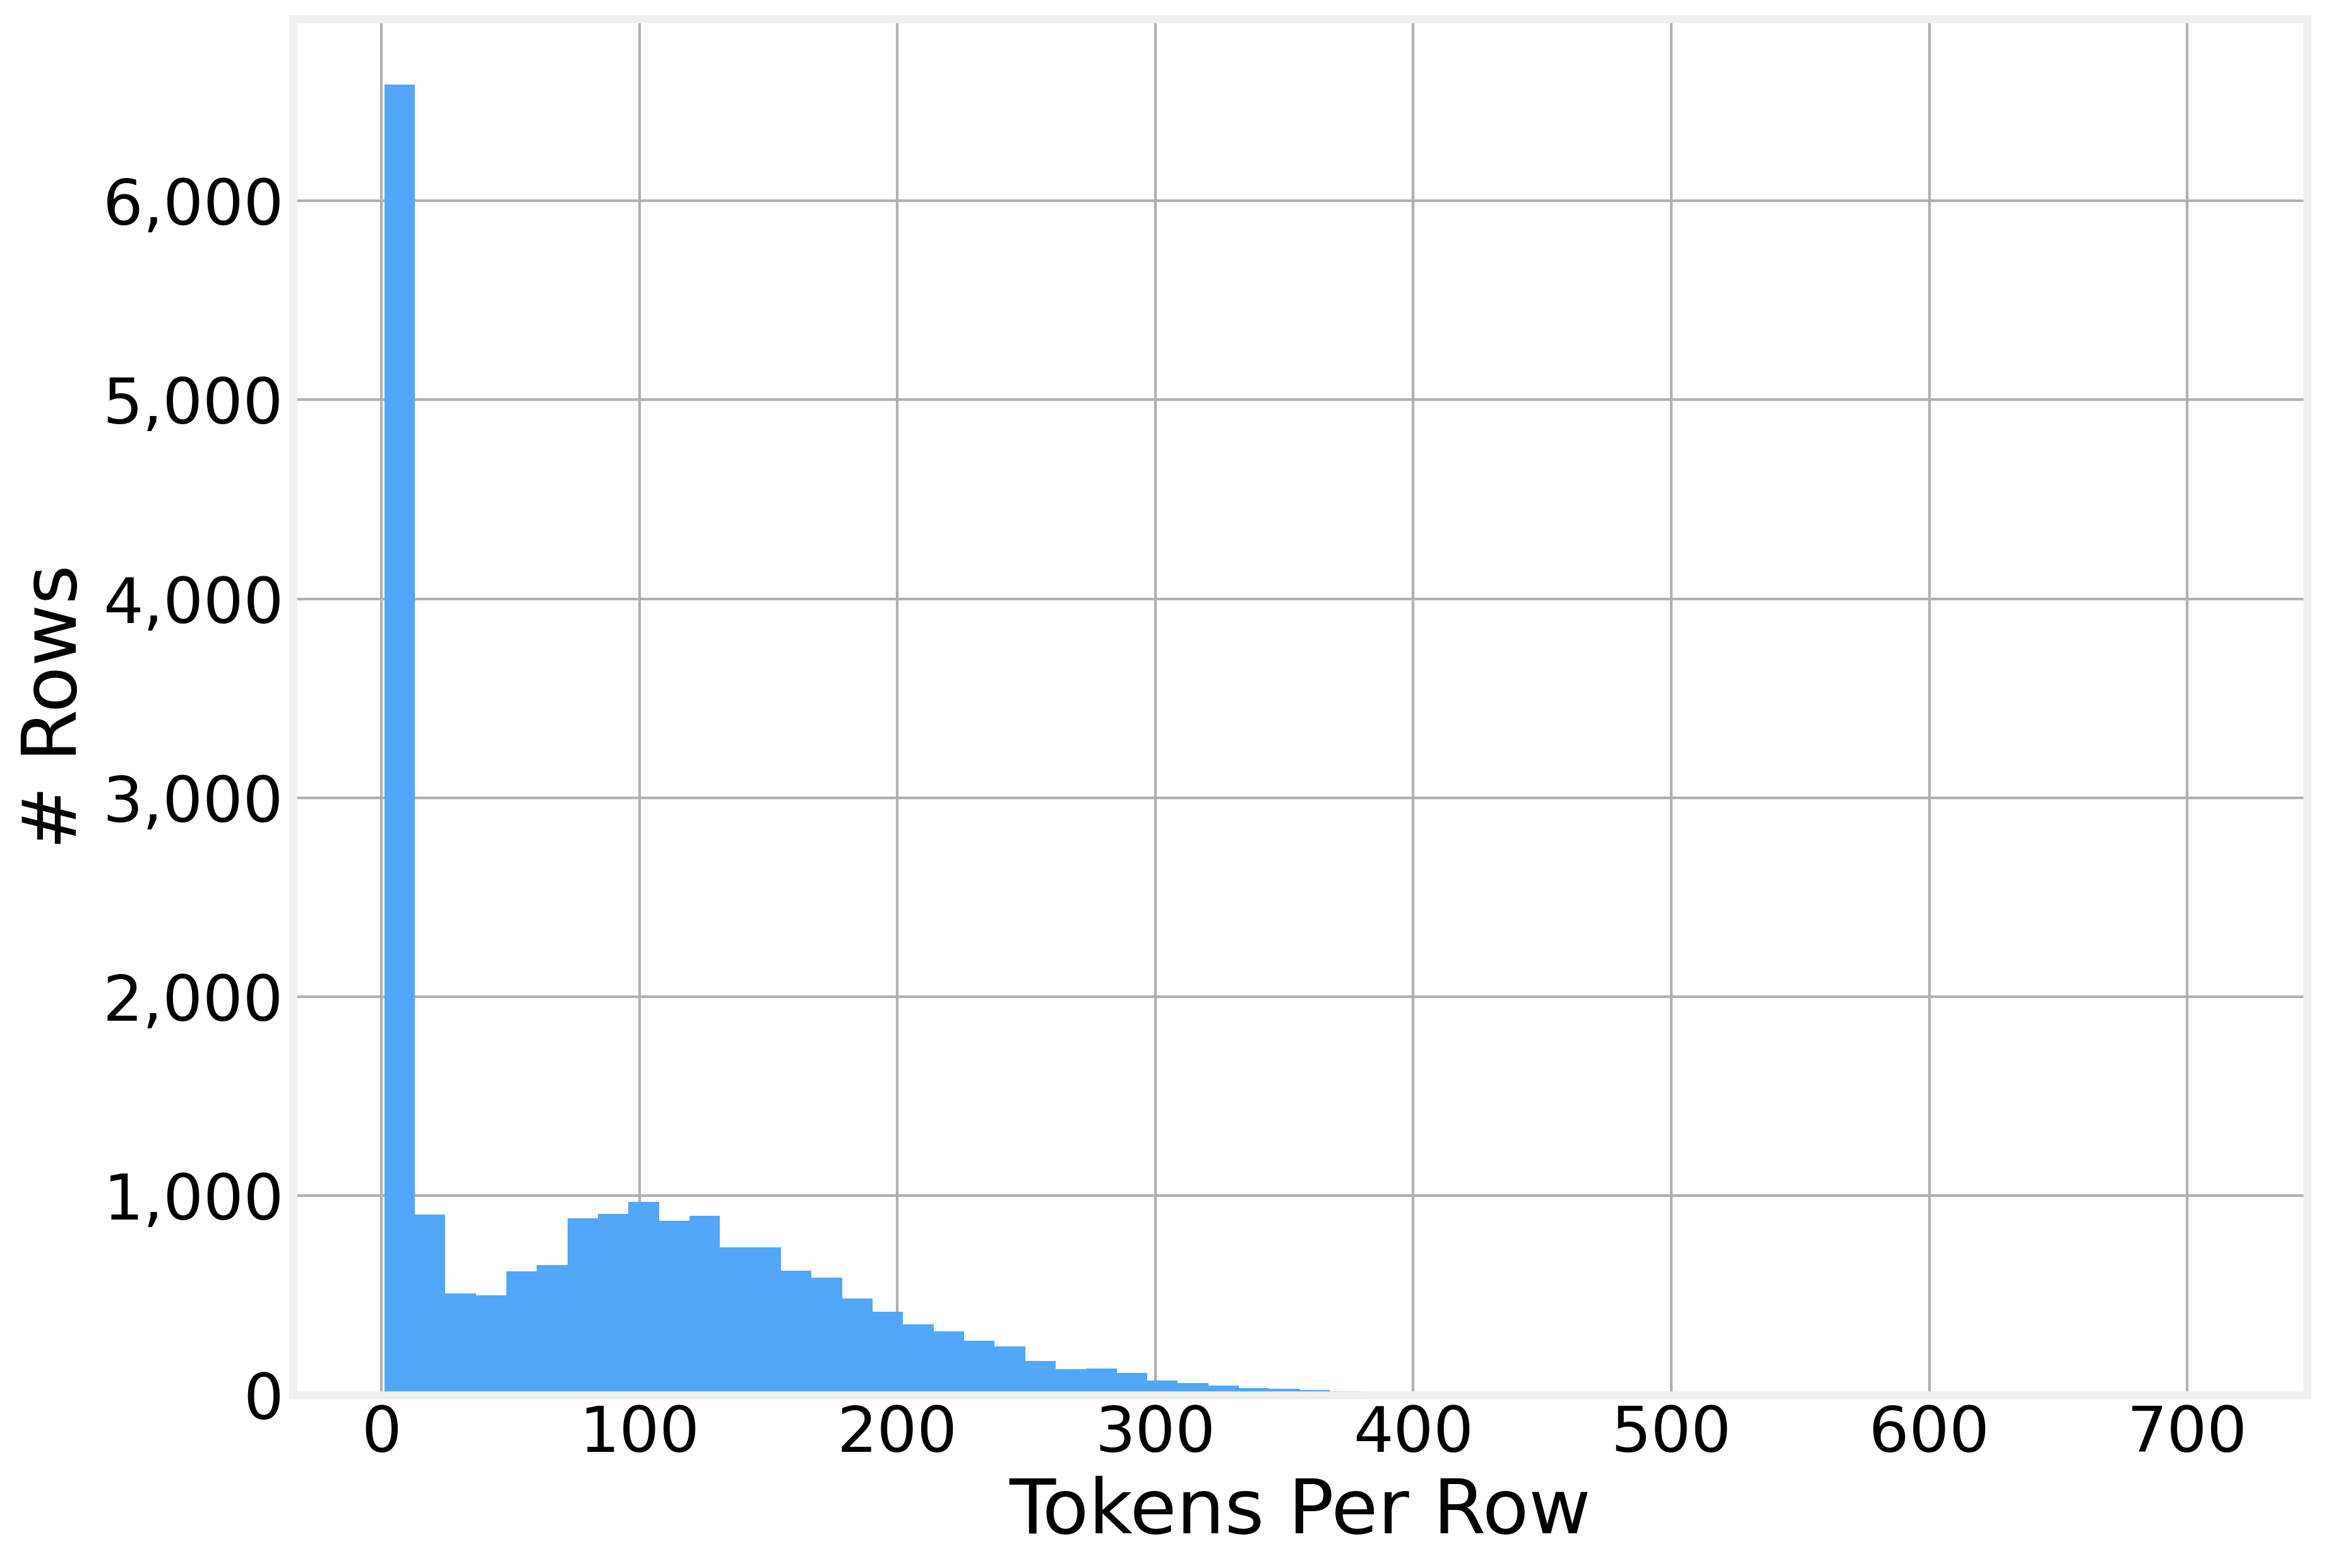

In [8]:
fig, ax = plt.subplots()
ax.hist(lengths, bins=60, color=colors[0])
ax.set_xlabel("Tokens Per Row")
ax.set_ylabel("# Rows")
ax.yaxis.set_major_formatter('{x:,.0f}')

## Which words appear most?

We pool the sampled tokens into one counter. The top of the list is no surprise. Function words like "the", "of", and the comma dominate. The bottom is a long tail of names, numbers, and rare terms that each show up once.

Distinct word types in sample: 68,641
Total word tokens in sample:   1,758,094


Text(0, 0.5, 'Frequency')

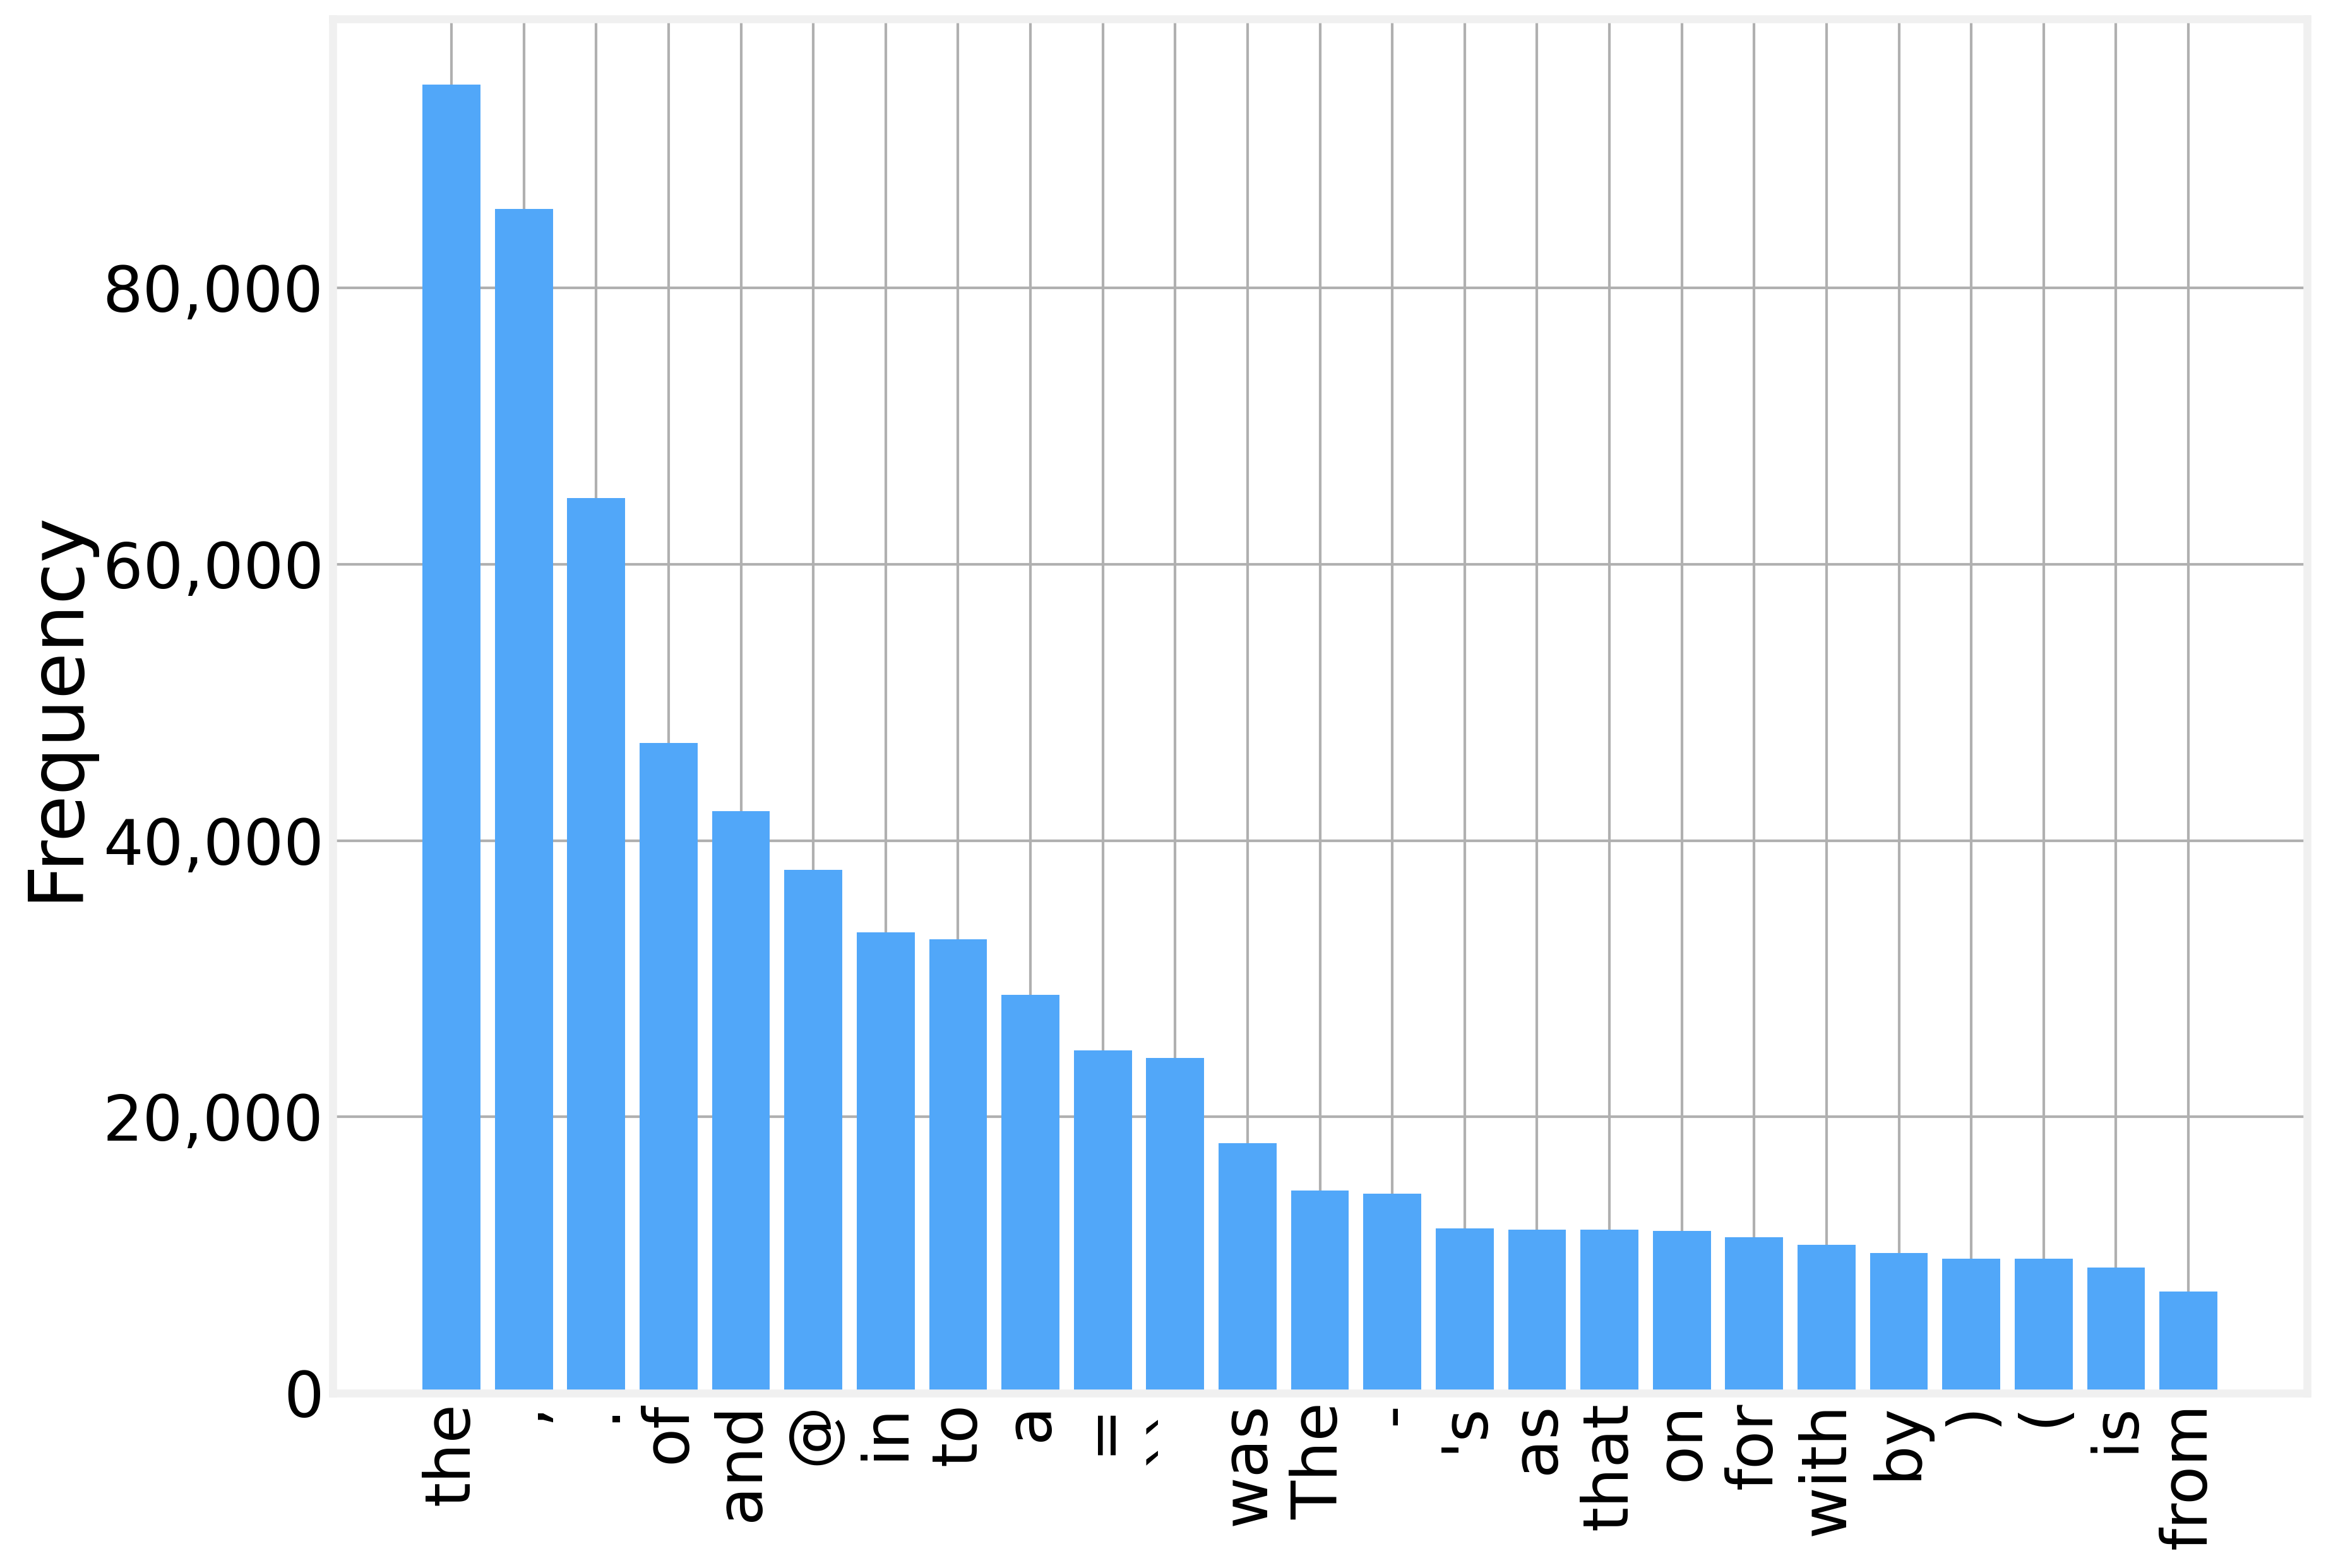

In [9]:
vocab = Counter()
for toks in sample_tokens:
    vocab.update(toks)

print(f"Distinct word types in sample: {len(vocab):,}")
print(f"Total word tokens in sample:   {sum(vocab.values()):,}")

top = vocab.most_common(25)
words = [w for w, c in top]
counts = [c for w, c in top]

fig, ax = plt.subplots()
ax.bar(range(len(words)), counts, color=colors[0])
ax.set_xticks(range(len(words)))
ax.set_xticklabels(words, rotation=90, ha="center")
ax.yaxis.set_major_formatter('{x:,.0f}')
ax.set_ylabel("Frequency")

## Zipf's law

Word frequencies follow a steep pattern. Rank the words from most to least common, then plot rank against frequency on log-log axes. The points fall along a near-straight line. The most common word appears about twice as often as the second, three times as often as the third, and so on down the list. This is Zipf's law, and it holds across languages and corpora.

Zipf's law is the root of the sparsity problem. A handful of words cover most of the text. The rest are rare. Any model that counts word combinations will see most combinations too few times to trust.

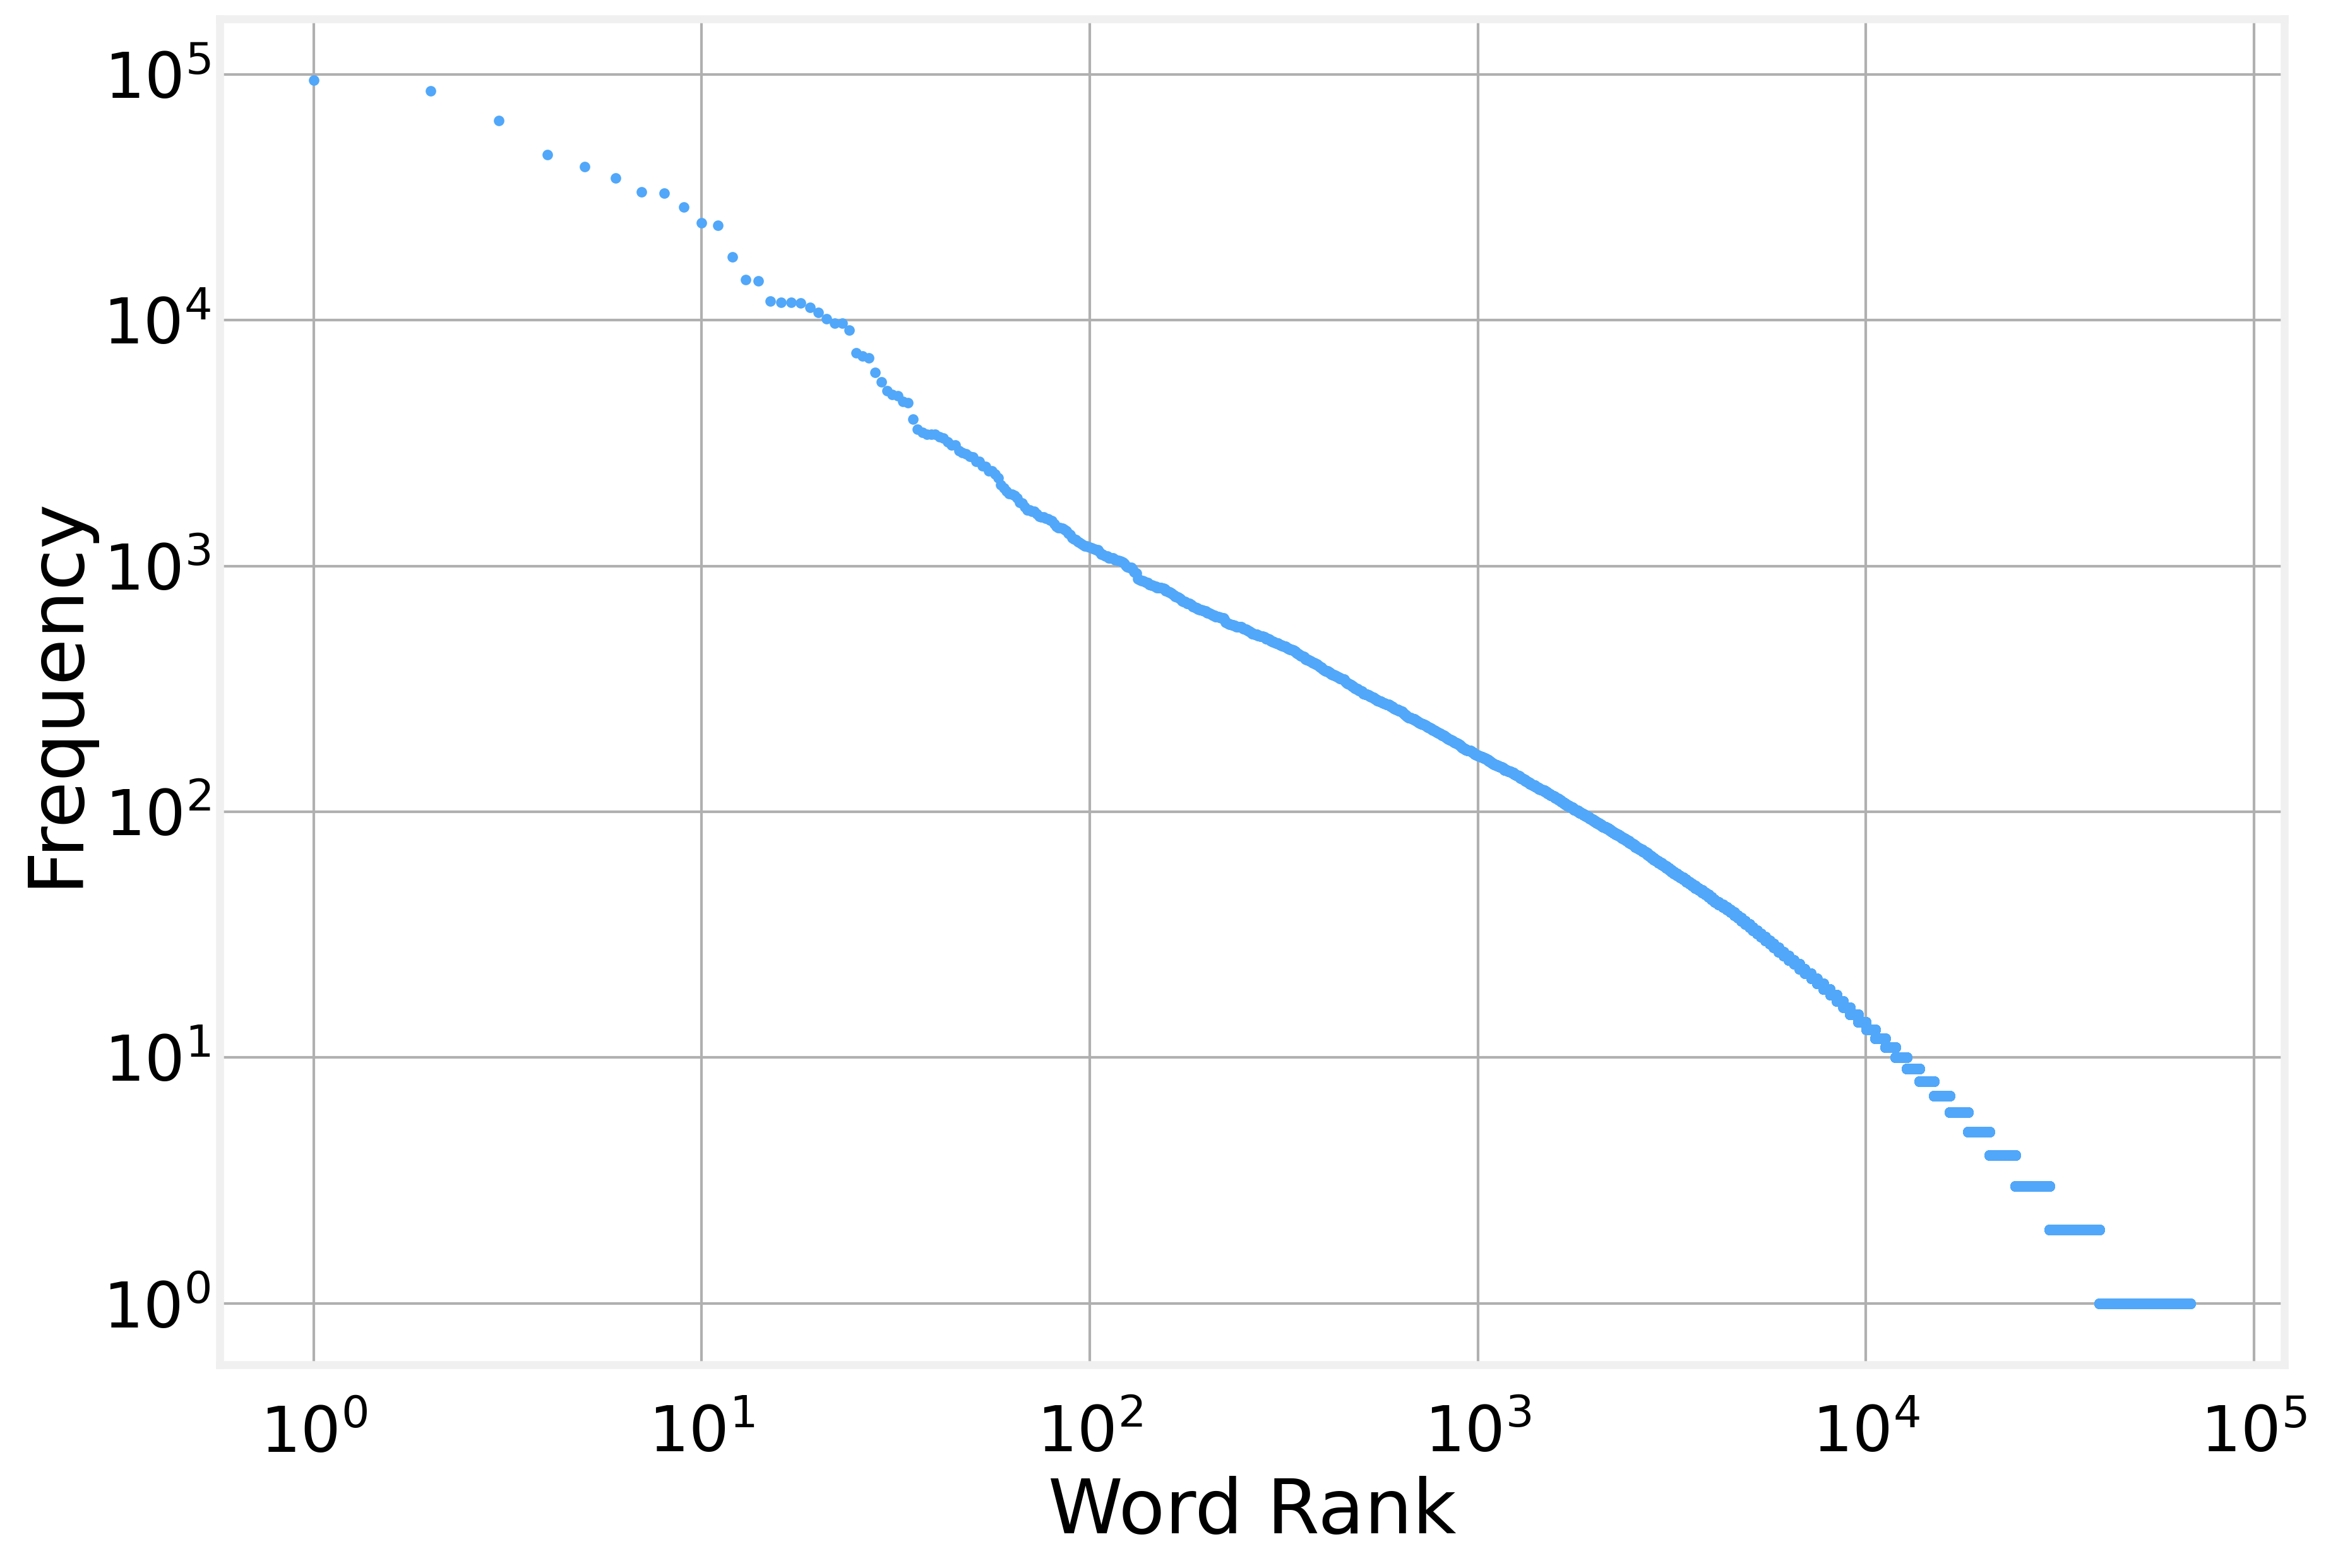

In [10]:
freqs = np.array(sorted(vocab.values(), reverse=True))
ranks = np.arange(1, len(freqs) + 1)

fig, ax = plt.subplots()
ax.loglog(ranks, freqs, marker=".", linestyle="none", color=colors[0])
ax.set_xlabel("Word Rank")
ax.set_ylabel("Frequency")
ax.tick_params(axis='x', pad=15)

## Counting the contexts

The model rests on three-word contexts, so let me count those directly. For the sampled text, how many distinct three-word contexts appear, and how many different words follow each one?

The answer drives everything that comes later. Most contexts appear once and carry a single continuation. The model has no real choice for those. It saw one word follow, and it will repeat that word. Only the common contexts offer several options with spread-out probabilities. This split explains why the generator sounds fluent in short bursts and slides into copied text over longer runs.

In [11]:
# Map each 3-word context to the set of words seen after it (4-grams, padded).
context_nextwords = defaultdict(set)
for toks in sample_tokens:
    for w1, w2, w3, w4 in ngrams(toks, 4, pad_right=True, pad_left=True):
        context_nextwords[(w1, w2, w3)].add(w4)

continuations = np.array([len(nexts) for nexts in context_nextwords.values()])

n_contexts = len(continuations)
n_single = int((continuations == 1).sum())
print(f"Distinct 3-word contexts in sample:   {n_contexts:,}")
print(f"Contexts with exactly one next word:  {n_single:,} ({100 * n_single / n_contexts:.1f}%)")
print(f"Mean next words per context:          {continuations.mean():.2f}")
print(f"Most next words for a single context: {continuations.max()}")

Distinct 3-word contexts in sample:   1,243,344
Contexts with exactly one next word:  1,121,597 (90.2%)
Mean next words per context:          1.25
Most next words for a single context: 3875


Text(0, 0.5, '# Contexts (log scale)')

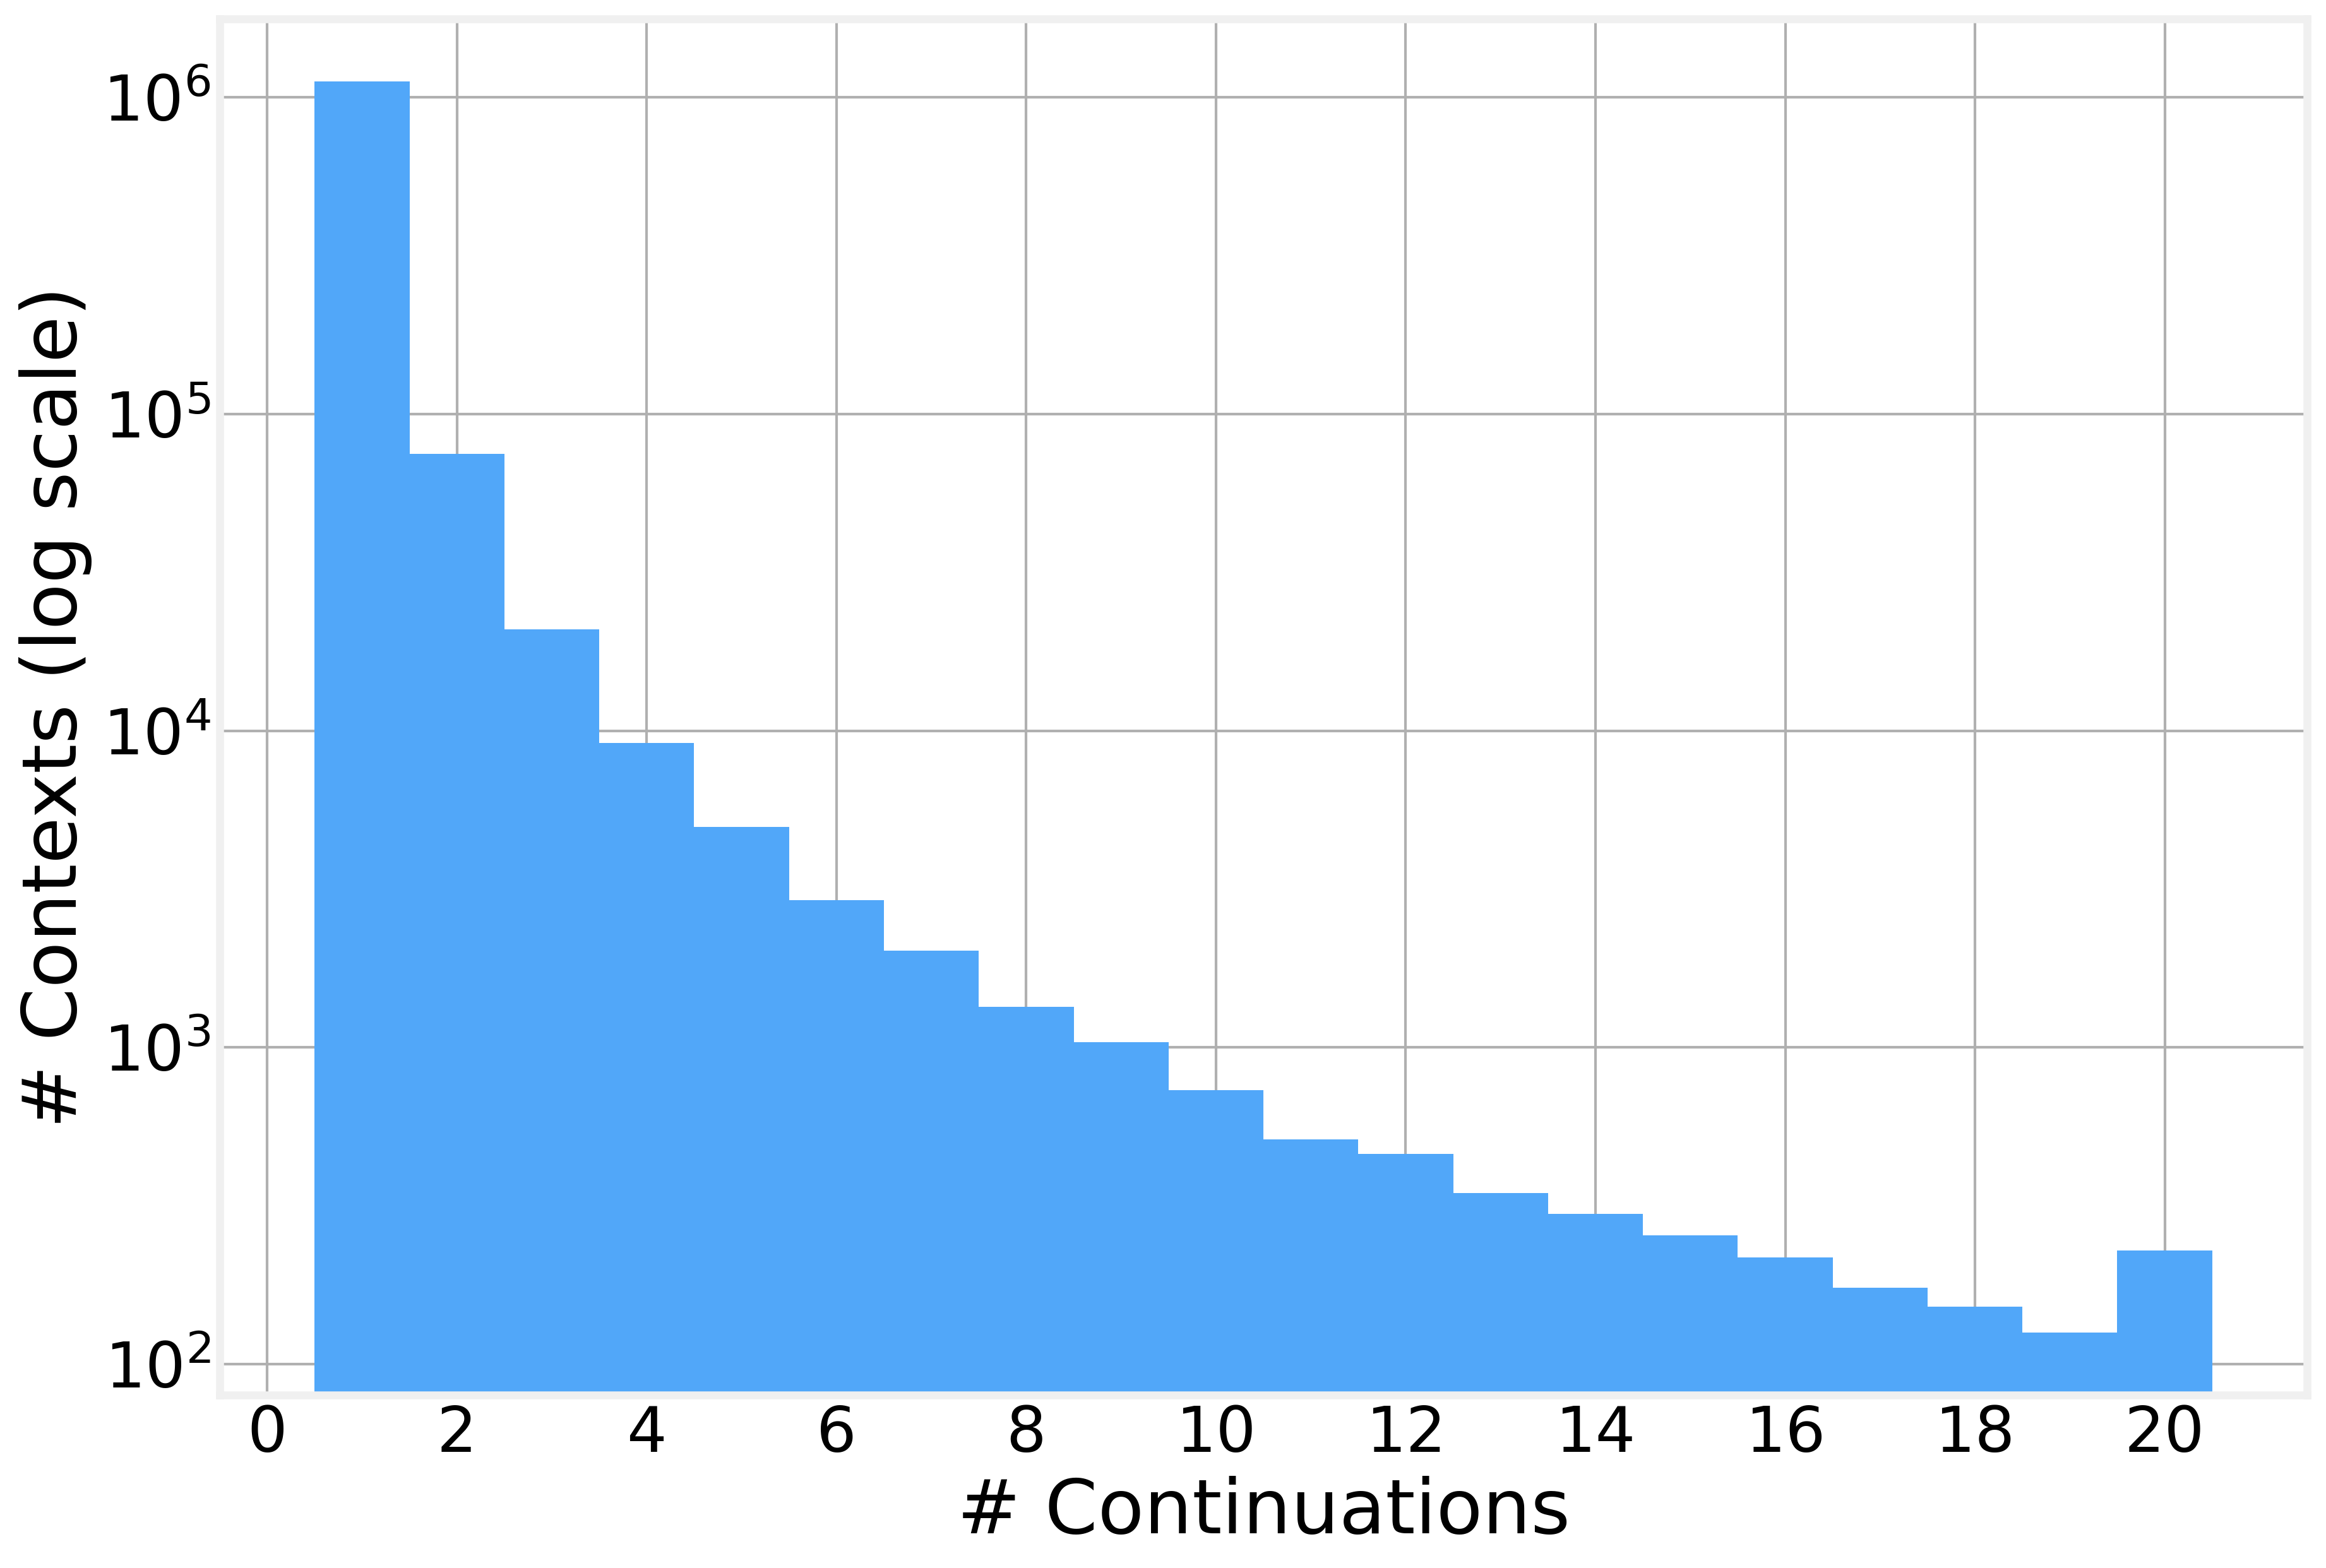

In [12]:
fig, ax = plt.subplots()
ax.hist(continuations, bins=range(1, 22), color=colors[0], align="left")
ax.set_xticks(np.arange(0, 21, 2))
ax.set_xticklabels(np.arange(0, 21, 2, dtype='int'))
ax.set_yscale("log")
ax.set_xlabel("# Continuations")
ax.set_ylabel("# Contexts (log scale)")

# What is a language model?

A language model answers one question. Given some words, what word comes next? Feed it "the United States of" and a good model puts high probability on "America". Feed it "I poured milk into my" and it favors "coffee" or "cereal" over "elephant". The model does not store facts in any deep sense. It stores how often words follow other words.

We can write this as a probability. For a sequence of words $w_1$ to $w_T$, the model gives the chance of the whole sequence:

$$P(w_1, w_2, \dots, w_T) = \prod_{t=1}^{T} P(w_t \mid w_1, \dots, w_{t-1})$$

Each factor is the probability of one word given everything before it. The product rule turns a sentence into a chain of next-word guesses. This is the only task. Everything else is detail about how we estimate those probabilities.

# Building the model

We now build the full 4-gram model over the whole training split, not just the sample. At each position we record the three-word context and the word that follows. The result maps each context to a count of next words.

The full pass over 103 million words runs for several minutes. We cache the finished table to disk and reload it on later runs.

A small helper sets up the nested counter. The outer dictionary is keyed by a three-word context. Each inner dictionary counts how often a given word follows that context.

In [13]:
def next_word_counts():
    return defaultdict(int)

model = defaultdict(next_word_counts)

In [14]:
CACHE_FILE = "data/wikitext_quadgram_model.pkl"

if os.path.exists(CACHE_FILE):
    print(f"Loading cached model from {CACHE_FILE}")
    with open(CACHE_FILE, "rb") as f:
        model = pickle.load(f)
else:
    # Count next-word occurrences for every 3-word context.
    model = defaultdict(next_word_counts)

    for item in tqdm(wikitext, desc="Counting 4-grams"):
        text = item["text"]
        if not text.strip():
            continue
        tokens = word_tokenize(text)
        # Pad so the first and last words get full contexts,
        # and so None marks where sentences start and end.
        for w1, w2, w3, w4 in ngrams(tokens, 4, pad_right=True, pad_left=True):
            context = (w1, w2, w3)
            model[context][w4] += 1

    # Store a plain dict so the pickle does not depend on the factory function.
    model = {context: dict(next_words) for context, next_words in model.items()}

    os.makedirs("data", exist_ok=True)
    with open(CACHE_FILE, "wb") as f:
        pickle.dump(model, f)
    print(f"Model cached to {CACHE_FILE}")

print(f"Distinct contexts in the model: {len(model):,}")

Loading cached model from data/wikitext_quadgram_model.pkl
Distinct contexts in the model: 41,277,266


We turn the raw counts into probabilities. For each context, we divide every next-word count by the total count for that context. The numbers for each context now sum to one.

In [15]:
for context in model:
    total_count = float(sum(model[context].values()))

    for word in model[context]:
        model[context][word] /= total_count

The model is a weighted map from each context to its possible next words. Let me read off the distribution for the context "the United States". The values are probabilities, and they add up to one.

In [16]:
model[("the", "United","States")]

{'Government': 0.001380937311199977,
 'Arsenal': 2.8769527316666188e-05,
 'and': 0.07137719727264881,
 '.': 0.17989585431111366,
 'Navy': 0.019908512903133002,
 'Bureau': 0.0009781639287666504,
 'came': 0.0004315429097499928,
 '(': 0.00641560459161656,
 'Assay': 0.0003164648004833281,
 'was': 0.008717166776949855,
 'which': 0.0010069334560833165,
 'Marine': 0.003509882332633275,
 'occupation': 0.0008343162921833194,
 'under': 0.0014960154204666418,
 ',': 0.17526396041313042,
 'of': 0.007854080957449869,
 'in': 0.038090854167266035,
 'Revenue': 0.00025892574584999566,
 'Court': 0.004948358698466584,
 'Constitution': 0.007940389539399868,
 'District': 0.0037400385511666043,
 'brought': 8.630858194999857e-05,
 'during': 0.00520728444431658,
 'to': 0.018067263154866366,
 'with': 0.006156678845766564,
 'on': 0.07080180672631549,
 '``': 0.004631893897983256,
 'for': 0.010702264161799821,
 "'": 0.013377830202249776,
 'Census': 0.002013866912166633,
 'Post': 0.0005753905463333237,
 'prior': 0.

## Generating text

Now we let the model write. We start from a three-word prompt and ask for the next word. We append that word, slide the context forward by one, and ask again. We repeat until the model emits the end-of-sentence marker. This loop, feed the output back in and predict the next token, is called autoregressive generation. It is the same loop that produces text in every large language model.

The function below has a temperature switch. With temperature off, it always picks the single most likely next word. This is greedy decoding. With temperature on, it samples a word at random in proportion to the probabilities, so rare words get an occasional turn. Large language models expose this same knob. A low temperature gives safe, repetitive text. A higher temperature gives variety and surprise.

In [17]:
def generate_sentence_from_prompt(model, prompt, zero_temperature=False):
    text = [*prompt]

    # We do not fix the sentence length up front.
    while True:
        # The current context is the last three words of the running text.
        context = tuple(text[-3:])

        # An unseen context has no continuations. Stop if we land on one.
        if context not in model:
            break

        # Pull the candidate next words and their probabilities.
        words = []
        probs = []
        for word, prob in model[context].items():
            words.append(word)
            probs.append(prob)

        if zero_temperature:
            # Always take the most likely word. Temperature = 0.
            pos = np.argmax(probs)
        else:
            # Sample one word in proportion to its probability. Temperature = 1.
            selection = np.random.multinomial(1, probs)
            pos = np.argmax(selection)

        word = words[pos]

        # Add the chosen word to the running text.
        text.append(word)

        # Three None tokens in a row mark the end of a sentence. Stop there.
        if text[-3:] == [None, None, None]:
            break

        # Guard against a runaway greedy loop.
        if zero_temperature and len(text) > 100:
            break

    return " ".join([t for t in text if t])

In [18]:
output = generate_sentence_from_prompt(model, ("the", "United", "States"))
print(output)

the United States ) , Tell Qannas ( Belgium )


A different prompt pulls a different chain of counts. Here we start from "United Kingdom of".

In [19]:
output = generate_sentence_from_prompt(model, ("United", "Kingdom", "of"))
print(output)

United Kingdom of Great Britain and Ireland = = = Breakout season : 2011 = = = Cinematography = = =


Same prompt, two temperatures. Greedy decoding repeats the most common path and often locks into a loop. Sampling stays varied. Run the cell a few times and the sampled output changes every run.

In [20]:
prompt = ("the", "United", "States")

print("Greedy (temperature = 0):")
print(generate_sentence_from_prompt(model, prompt, zero_temperature=True))

print("\nSampled (temperature = 1):")
print(generate_sentence_from_prompt(model, prompt))

Greedy (temperature = 0):
the United States .

Sampled (temperature = 1):
the United States , known as Operation Y @ - @ quarters of the division did not immediately translate into league and FA Cup . Anfield itself was in the `` rockers `` or `` swishes `` , the deprivation `` of the computer Watson .


<center>
     <img src="https://raw.githubusercontent.com/DataForScience/Networks/master/data/D4Sci_logo_full.png" alt="Data For Science, Inc" align="center" border="0" width=300px> 
</center>